# CosMx Human Non-Small Cell Lung Cancer Dataset

### Gene set activity quantification and EMT-niche analysis

This notebook demonstrates GESSO on the CosMx human non-small cell lung cancer (NSCLC) 3D-ECM dataset (Pentimalli et al., *Cell Systems*, 2025; available at [Zenodo record 15240431](https://zenodo.org/records/15240431)), specifically section 22 (~58k cells).

Pathways scored:

- `TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL` - tumor core
- `TRAVAGLINI_LUNG_ADVENTITIAL_FIBROBLAST_CELL` - desmoplastic stroma
- `TRAVAGLINI_LUNG_PROLIFERATING_MACROPHAGE_CELL` - macrophage niche
- `GOBP_T_CELL_ACTIVATION` - T cell niche
- `FOROUTAN_PRODRANK_TGFB_EMT_UP` - EMT niche (TGFβ-induced EMT program)

### Import the `gesso` package.

The `gesso` Python package can be easily downloaded from source. Simply run the following script in your terminal after ensuring Python and pip are available in your environment. We recommend installing GESSO in a new Python environment.

```bash
git clone https://github.com/YMa-Lab/GESSO.git
cd GESSO
pip install .
cd ..
```

Reading CosMx `.Rds` files additionally requires `pyreadr`:

```bash
pip install pyreadr
```

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

project_directory = Path("__notebook__").resolve().parent.parent
sys.path.append(str(project_directory))

from gesso import GESSO

### Configure logging (optional)

In [ ]:
from gesso import logging as glog

glog.enable()
glog.silence_per_geneset();  # keep summaries, mute per-geneset progress


### Load the spatial transcriptomics data

In [3]:
cosmx_data_dir = Path("/users/ayang103/data/Project/SPLAGE/ST_Data/CosMx_ECM3D")
pathways_csv = Path(
    "/users/ayang103/data/Project/SPLAGE/Target_Pathway_List/PathwaysTable/used_geneset"
    "/CosMx.NSCLC3D.PathwaysTable.0702.csv"
)

count_rds = cosmx_data_dir / "section_22_Count.Rds"
metadata_rds = cosmx_data_dir / "section_22_Metadata.Rds"
for p in (count_rds, metadata_rds, pathways_csv):
    assert p.exists(), p

In [4]:
# count matrix: genes x cells, transpose to cells x genes for GESSO
t0 = time.time()
expression_df: pd.DataFrame = pyreadr.read_r(str(count_rds))[None]
expression_df.columns.name = None
expression_df.index.name = None
expression_df = expression_df.T
print(f"loaded count matrix in {time.time() - t0:.1f}s; shape (cells x genes) = {expression_df.shape}")
display(expression_df.iloc[:5, :8])

loaded count matrix in 5.2s; shape (cells x genes) = (57993, 960)


,AATK,ABL1,ABL2,ACE,ACE2,ACKR1,ACKR3,ACKR4
section_22_fov_1_ID_1,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
section_22_fov_1_ID_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
section_22_fov_1_ID_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
section_22_fov_1_ID_4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
section_22_fov_1_ID_5,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0


In [ ]:
metadata_df: pd.DataFrame = pyreadr.read_r(str(metadata_rds))[None]
metadata_df.columns.name = None
metadata_df.index.name = None
print("metadata shape:", metadata_df.shape)
display(metadata_df[["x_2D_px", "y_2D_px", "celltypes", "niches_2D", "in_EMT_niche"]].head())

metadata shape: (57993, 63)


,x_2D_px,y_2D_px,celltypes,niches_2D,in_EMT_niche
section_22_fov_1_ID_1,21290.0,3613.0,Vascular endothelium,Vascular stroma,False
section_22_fov_1_ID_2,20855.0,3619.0,Regulatory T cells,T cell niches,False
section_22_fov_1_ID_3,19758.0,3607.0,Tumor cells,Tumor core,False
section_22_fov_1_ID_4,19584.0,3584.0,Tumor cells,Tumor core,False
section_22_fov_1_ID_5,19465.0,3619.0,Basal epithelial cells,Tumor core,False


Filter cells to those with at least 50 total counts and align expression rows with the metadata index.

In [ ]:
# >=50 total counts
spot_total_counts = expression_df.sum(axis=1)
keep_counts = spot_total_counts >= 50
print(f"cells passing >=50 counts: {int(keep_counts.sum())} / {len(keep_counts)}")

expression_df = expression_df.loc[keep_counts]

# align with metadata on cell IDs
common_cells = expression_df.index.intersection(metadata_df.index)
expression_df = expression_df.loc[common_cells]
metadata_df = metadata_df.loc[common_cells]

# GESSO locations dataframe
locations_df = metadata_df[["x_2D_px", "y_2D_px"]].rename(
    columns={"x_2D_px": "x", "y_2D_px": "y"}
).astype(float)

print("expression shape (cells x genes):", expression_df.shape)
print("locations shape:", locations_df.shape)
display(locations_df.head())

cells passing >=50 counts: 57993 / 57993


expression shape (cells x genes): (57993, 960)
locations shape: (57993, 2)


,x,y
section_22_fov_1_ID_1,21290.0,3613.0
section_22_fov_1_ID_2,20855.0,3619.0
section_22_fov_1_ID_3,19758.0,3607.0
section_22_fov_1_ID_4,19584.0,3584.0
section_22_fov_1_ID_5,19465.0,3619.0


Load the gene-set membership matrix, restricting to five pathways. The pathway table is a $G \times n_\text{genesets}$ binary matrix.

In [ ]:
pathways = [
    "TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL",
    "TRAVAGLINI_LUNG_ADVENTITIAL_FIBROBLAST_CELL",
    "TRAVAGLINI_LUNG_PROLIFERATING_MACROPHAGE_CELL",
    "GOBP_T_CELL_ACTIVATION",
    "FOROUTAN_PRODRANK_TGFB_EMT_UP",
]
genesets_df = pd.read_csv(
    pathways_csv, index_col=0, usecols=["Unnamed: 0", *pathways]
)
genesets_df = genesets_df[pathways]  # column order
genesets_df.columns.name = None
genesets_df.index.name = None
for pw in pathways:
    print(f"{pw}: {int(genesets_df[pw].sum())} genes in CosMx panel")
display(genesets_df.iloc[:5])

TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL: 65 genes in CosMx panel
TRAVAGLINI_LUNG_ADVENTITIAL_FIBROBLAST_CELL: 75 genes in CosMx panel
TRAVAGLINI_LUNG_PROLIFERATING_MACROPHAGE_CELL: 124 genes in CosMx panel
GOBP_T_CELL_ACTIVATION: 163 genes in CosMx panel
FOROUTAN_PRODRANK_TGFB_EMT_UP: 47 genes in CosMx panel


,TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL,TRAVAGLINI_LUNG_ADVENTITIAL_FIBROBLAST_CELL,TRAVAGLINI_LUNG_PROLIFERATING_MACROPHAGE_CELL,GOBP_T_CELL_ACTIVATION,FOROUTAN_PRODRANK_TGFB_EMT_UP
AATK,0,0,0,0,0
ABL1,0,1,0,1,0
ABL2,0,1,0,1,0
ACE,0,0,0,0,0
ACE2,0,0,0,0,0


### Use GESSO to compute gene set activity scores

For ~58k cells we use the `lowres` method with `n_partitions=10` (~5,800 cells per partition) and `stratified_kmeans` partitioning. Each of the 5 gene sets is scored across all 10 spatial partitions, which the `Parallel` pool processes concurrently.

In [ ]:
model = GESSO(
    expression_df=expression_df,
    locations_df=locations_df,
    genesets_df=genesets_df,
    k=20,                                 # number of nearest-neighbor edges for the spatial graph
    normalize_counts_method="normalize-log1p",
)

start = time.time()
gas_report = model.compute_gas(
    genesets=pathways,
    beta=0.33,                            # spatial smoothing strength
    compute_method="lowres",              # scalable estimator for high-resolution data
    partition_method="stratified_kmeans",
    n_partitions=10,
    n_jobs=20,
    store_gene_contributions=True,
)
print(f"compute_gas done in {time.time() - start:.1f} s for {len(pathways)} gene sets")

gas_df = gas_report.gas_df()
display(gas_df.head())

GESSO (info): Identified 960 common genes in the gene set and expression data. 


GESSO (info): Identified 57993 common spots in the location and expression data. 


GESSO (info): Normalized expression data with strategy 'normalize-log1p'. 


GESSO (info): Model initialization complete. 


GESSO (info): Beginning low resolution activity score computation for 5 gene sets with 5 
               jobs. Method used: lowres. 


compute_gas done in 99.7 s for 5 gene sets


,TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL,TRAVAGLINI_LUNG_ADVENTITIAL_FIBROBLAST_CELL,TRAVAGLINI_LUNG_PROLIFERATING_MACROPHAGE_CELL,GOBP_T_CELL_ACTIVATION,FOROUTAN_PRODRANK_TGFB_EMT_UP
section_22_fov_1_ID_1,-2.699694,-1.645662,0.174056,-1.023556,0.771783
section_22_fov_1_ID_2,-1.747796,-0.850772,1.699003,1.707946,-1.099110
section_22_fov_1_ID_3,3.387635,-2.468578,-2.451914,-0.724324,-0.944858
section_22_fov_1_ID_4,5.418164,-2.737936,-2.478748,-1.364351,-2.103028
section_22_fov_1_ID_5,0.618019,0.024656,-0.645437,-1.406777,-1.199882


Top gene contributions per pathway recover well-established marker genes: epithelial / tumorigenic genes for the alveolar-type-1 program (e.g. *CLDN4*, *EPCAM*, *KRT19*), collagen / matrix genes for the adventitial fibroblast program (*COL1A1*, *COL3A1*), and fibroblast / mesenchymal / matrix-remodeling genes for the TGFβ-EMT program (*COL1A1*, *COL5A1*, *FN1*, *MMP2*).

In [9]:
for pw in pathways:
    top = gas_report.gene_contributions_df(geneset=pw).head(8)
    print(f"\n=== top contributors: {pw} ===")
    print(top)


=== top contributors: TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL ===
         TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL
CLDN4                                           0.284582
ITGA3                                           0.275478
EPCAM                                           0.271797
KRT19                                           0.264341
VEGFA                                           0.258548
S100A10                                         0.258174
KRT7                                            0.225759
TM4SF1                                          0.221621

=== top contributors: TRAVAGLINI_LUNG_ADVENTITIAL_FIBROBLAST_CELL ===
        TRAVAGLINI_LUNG_ADVENTITIAL_FIBROBLAST_CELL
COL3A1                                     0.312670
COL1A2                                     0.307957
COL1A1                                     0.280837
COL6A3                                     0.259313
LUM                                        0.253207
DCN                          

### Visualize spatial maps for the five pathways

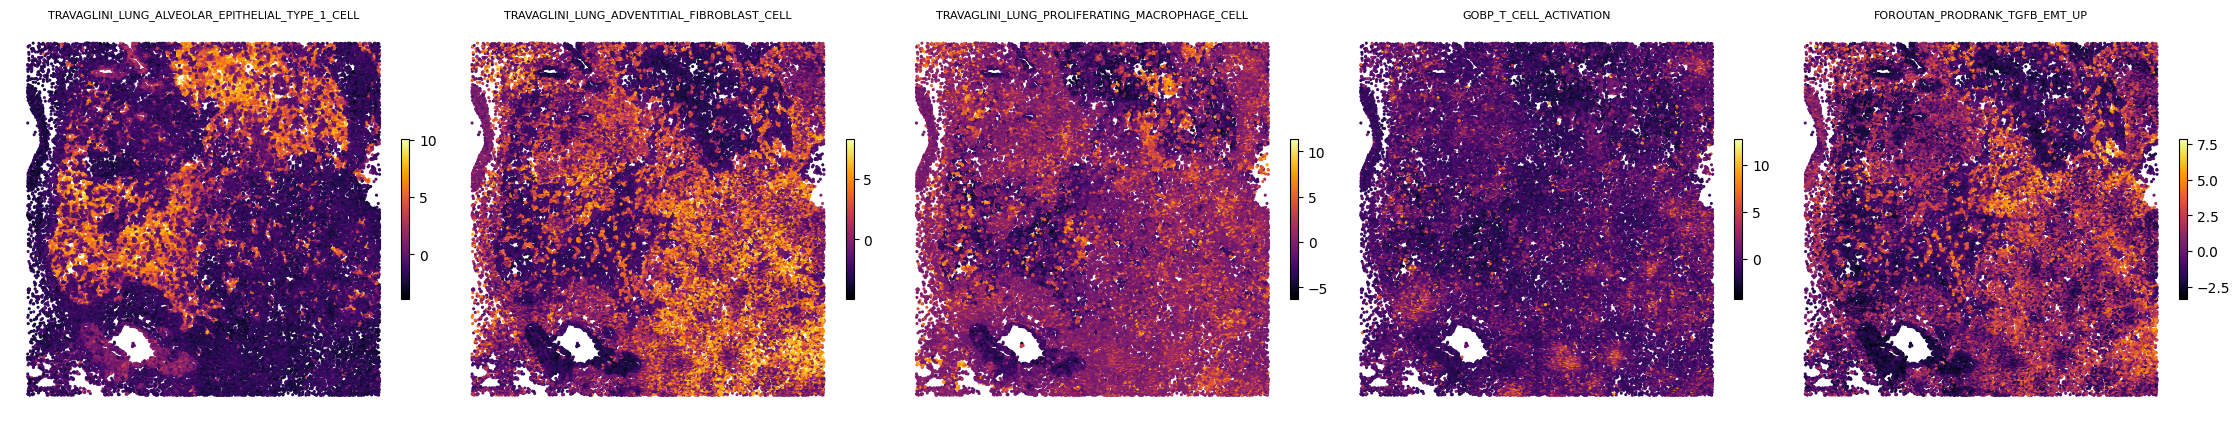

In [10]:
fig, axes = plt.subplots(1, len(pathways), figsize=(4.5 * len(pathways), 4.5))
for ax, pw in zip(axes, pathways):
    gas_report.plot_gas_spatial_map(
        geneset=pw, size=1.5, cmap="inferno", figsize=(4.5, 4.5), ax=ax,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.set_title(pw, fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

### Downstream: EMT-niche enrichment

The metadata column `in_EMT_niche` (boolean) marks the ~4,000 cells inside an EMT niche. The GAS for the TGFβ-induced EMT pathway `FOROUTAN_PRODRANK_TGFB_EMT_UP` is strongly elevated specifically within this niche.

We assess this two ways:

1. **Distribution split**: violin/boxplot of each pathway's GAS for in-niche vs. out-of-niche cells.
2. **Spatial overlay**: the EMT GAS map alongside the niche mask, so that the agreement is visible by eye.

We also report a one-sided Mann-Whitney $U$ test for EMT GAS in-niche > EMT GAS out-of-niche.

In [11]:
emt_pw = "FOROUTAN_PRODRANK_TGFB_EMT_UP"

in_niche = metadata_df["in_EMT_niche"].astype(bool).to_numpy()
print(f"cells in EMT niche: {int(in_niche.sum())}  /  out: {int((~in_niche).sum())}")

# numeric summary across all 5 pathways, with formal test on the EMT pathway
summary_rows = []
for pw in pathways:
    values = gas_df[pw].to_numpy()
    inside = values[in_niche]
    outside = values[~in_niche]
    u_stat, p_one_sided = mannwhitneyu(inside, outside, alternative="greater")
    summary_rows.append({
        "pathway": pw,
        "mean_in_niche": float(inside.mean()),
        "mean_out_niche": float(outside.mean()),
        "delta_mean": float(inside.mean() - outside.mean()),
        "mwu_pvalue_in_gt_out": float(p_one_sided),
    })

summary_df = pd.DataFrame(summary_rows).set_index("pathway")
display(summary_df)
print(f"\nMann-Whitney U (one-sided, in-niche > out-of-niche) for {emt_pw}:")
print(f"  p = {summary_df.loc[emt_pw, 'mwu_pvalue_in_gt_out']:.2e}")
print(f"  delta(mean GAS) = {summary_df.loc[emt_pw, 'delta_mean']:.3f}")

cells in EMT niche: 4082  /  out: 53911


,mean_in_niche,mean_out_niche,delta_mean,mwu_pvalue_in_gt_out
pathway,,,,
TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL,0.645455,-0.050107,0.695562,3.088954e-130
TRAVAGLINI_LUNG_ADVENTITIAL_FIBROBLAST_CELL,0.179579,-0.031555,0.211135,7.659245e-08
TRAVAGLINI_LUNG_PROLIFERATING_MACROPHAGE_CELL,0.042903,0.003655,0.039248,9.999169e-01
GOBP_T_CELL_ACTIVATION,-0.615222,0.067794,-0.683016,1.000000e+00
FOROUTAN_PRODRANK_TGFB_EMT_UP,0.728262,-0.070010,0.798272,2.348064e-115



Mann-Whitney U (one-sided, in-niche > out-of-niche) for FOROUTAN_PRODRANK_TGFB_EMT_UP:
  p = 2.35e-115
  delta(mean GAS) = 0.798


/tmp/ipykernel_155033/1888786270.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


/tmp/ipykernel_155033/1888786270.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


/tmp/ipykernel_155033/1888786270.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


/tmp/ipykernel_155033/1888786270.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


/tmp/ipykernel_155033/1888786270.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


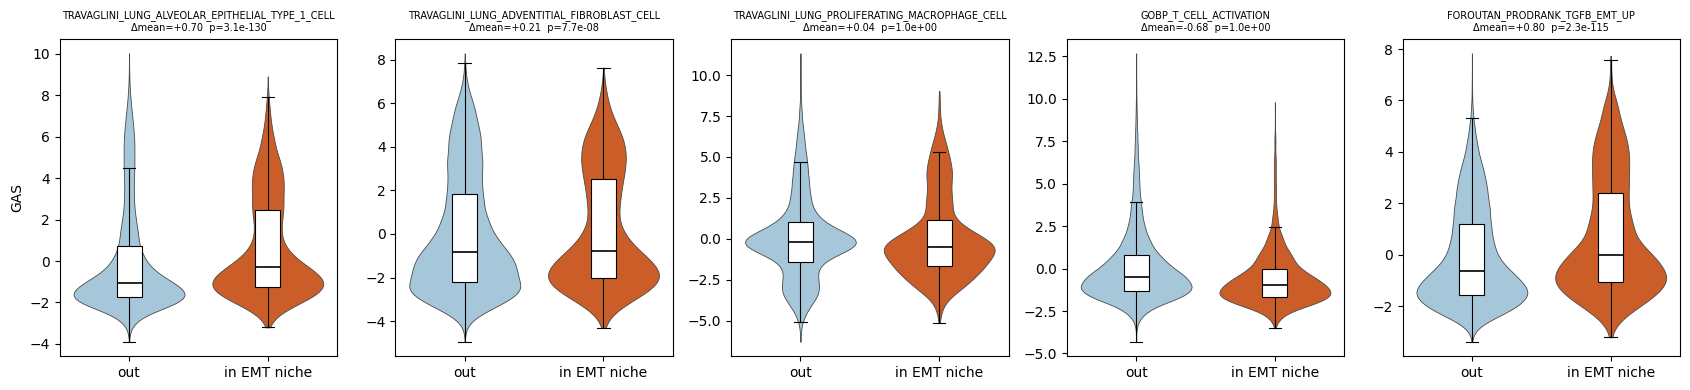

In [ ]:
niche_labels = np.where(in_niche, "in EMT niche", "out")
plot_records = []
for pw in pathways:
    plot_records.append(pd.DataFrame({
        "pathway": pw,
        "GAS": gas_df[pw].to_numpy(),
        "niche": niche_labels,
    }))
plot_df = pd.concat(plot_records, ignore_index=True)

fig, axes = plt.subplots(1, len(pathways), figsize=(3.4 * len(pathways), 4), sharey=False)
order = ["out", "in EMT niche"]
palette = {"out": "#9ecae1", "in EMT niche": "#e6550d"}
for ax, pw in zip(axes, pathways):
    sub = plot_df[plot_df["pathway"] == pw]
    sns.violinplot(
        data=sub, x="niche", y="GAS", order=order, palette=palette,
        inner=None, cut=0, linewidth=0.6, ax=ax,
    )
    sns.boxplot(
        data=sub, x="niche", y="GAS", order=order,
        width=0.18, showfliers=False, ax=ax,
        boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
        medianprops={"color": "black", "linewidth": 1.2},
        whiskerprops={"color": "black", "linewidth": 0.8},
        capprops={"color": "black", "linewidth": 0.8},
    )
    delta = summary_df.loc[pw, "delta_mean"]
    pval = summary_df.loc[pw, "mwu_pvalue_in_gt_out"]
    ax.set_title(f"{pw}\ndelta_mean={delta:+.2f}  p={pval:.1e}", fontsize=7)
    ax.set_xlabel("")
    ax.set_ylabel("GAS" if ax is axes[0] else "")
fig.tight_layout()
display(fig)
plt.close(fig)

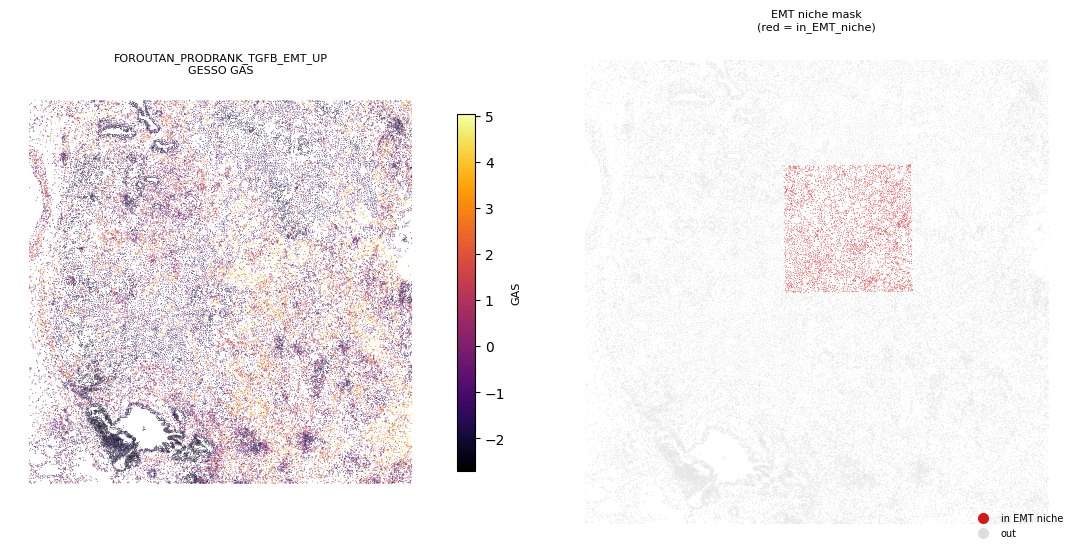

In [ ]:
emt_values = gas_df[emt_pw].to_numpy()
coords = locations_df[["x", "y"]].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

vmin = float(np.percentile(emt_values, 1))
vmax = float(np.percentile(emt_values, 99))
sc0 = axes[0].scatter(
    coords[:, 0], coords[:, 1], c=emt_values, cmap="inferno",
    s=1.5, marker=".", linewidths=0, vmin=vmin, vmax=vmax,
)
axes[0].set_aspect("equal", adjustable="box")
axes[0].invert_yaxis()
axes[0].set_xticks([]); axes[0].set_yticks([])
for spine in axes[0].spines.values():
    spine.set_visible(False)
axes[0].set_title(f"{emt_pw}\nGESSO GAS", fontsize=8)
cbar = fig.colorbar(sc0, ax=axes[0], shrink=0.7)
cbar.set_label("GAS", fontsize=8)

mask_color = np.where(in_niche, "#d7191c", "#dddddd")
order = np.argsort(in_niche.astype(int))  # draw in-niche on top
axes[1].scatter(
    coords[order, 0], coords[order, 1], c=mask_color[order],
    s=1.5, marker=".", linewidths=0,
)
axes[1].set_aspect("equal", adjustable="box")
axes[1].invert_yaxis()
axes[1].set_xticks([]); axes[1].set_yticks([])
for spine in axes[1].spines.values():
    spine.set_visible(False)
axes[1].set_title("EMT niche mask\n(red = in_EMT_niche)", fontsize=8)
legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color="#d7191c", label="in EMT niche", markersize=7),
    plt.Line2D([0], [0], marker="o", linestyle="", color="#dddddd", label="out", markersize=7),
]
axes[1].legend(handles=legend_handles, loc="lower right", fontsize=7, frameon=False)

fig.tight_layout()
display(fig)
plt.close(fig)